# Aufgabe 3

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.morphology import closing, disk, opening

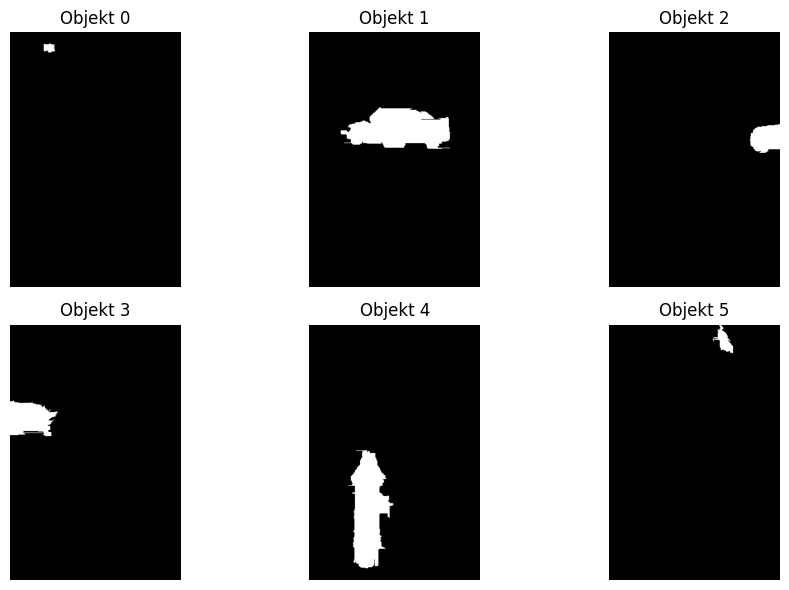

In [12]:
masks = [imread(f"objektmasken/objekt_{i}_bin.png") for i in range(6)]

plt.figure(figsize=(10, 6))
for i, mask in enumerate(masks):
    plt.subplot(2, 3, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Objekt {i}')
    plt.axis('off')
plt.tight_layout()

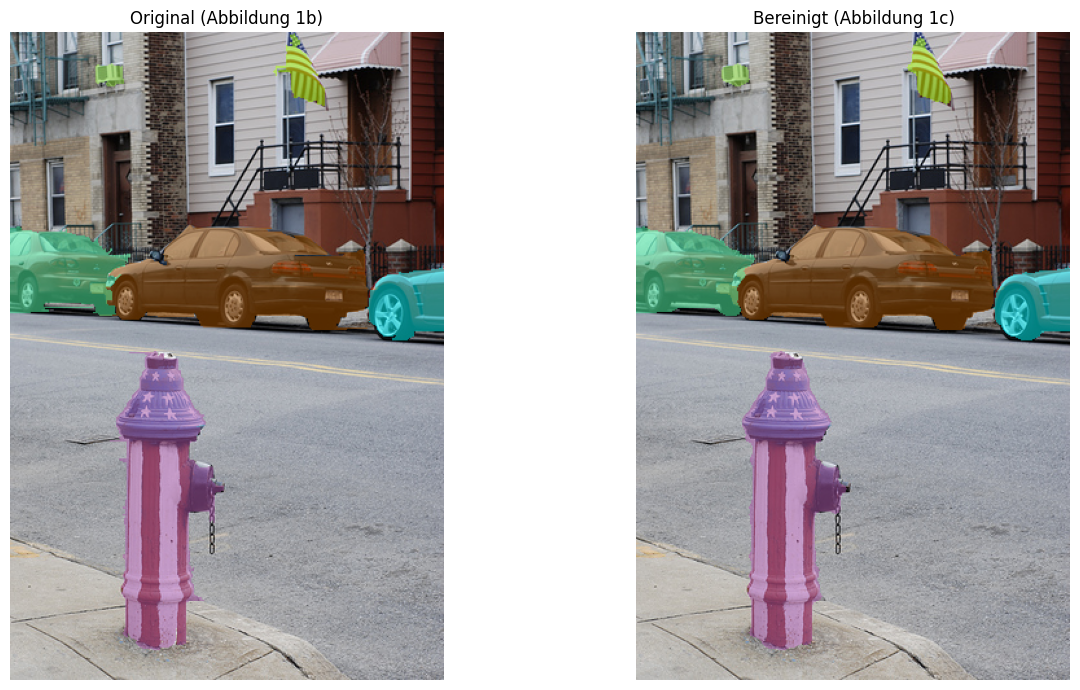

In [13]:

# Originalbild für Visualisierung laden
img = imread("293071.jpg")

# visMasks-Funktion (aus vis.ipynb)
def visMasks(img, masks):
    result = np.copy(img).astype(np.float64)
    colors = [(170, 255, 85), (170, 85, 0), (0, 255, 255), (85, 255, 170),
              (170, 85, 170), (170, 255, 0)]
    for i, labelImg in enumerate(masks):
        color = np.array(colors[i % len(colors)])
        mask3 = np.dstack([labelImg] * 3)
        colorMask = color * mask3
        result = result * (1 - mask3) + mask3 * result * .5 + colorMask * .5
    return result.astype(np.uint8)

# Strukturelement: Disk mit Radius 3 entfernt Strukturen schmaler als ~3 Pixel
se = disk(3)

masks_cleaned = []
for mask in masks:
    m = (mask > 0)
    # Closing: füllt dünne horizontale Einschnitte (Antennen, die aus der Maske ausgeschnitten sind)
    m_closed = closing(m, se)
    # Opening: entfernt dünne horizontale Fortsätze (Antennen, die aus der Maske hervorstechen)
    m_cleaned = opening(m_closed, se)
    masks_cleaned.append(m_cleaned)

# Vergleich: Original vs. bereinigt
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(visMasks(img, [m > 0 for m in masks]))
axes[0].set_title('Original (Abbildung 1b)')
axes[0].axis('off')
axes[1].imshow(visMasks(img, masks_cleaned))
axes[1].set_title('Bereinigt (Abbildung 1c)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
